# QB Evaluator: does fault-adjusted EPA beat raw EPA?

**Question.** If we adjust each QB's EPA for *who was at fault* (bad-throw interceptions vs. tipped or
receiver-caused ones, receiver drops, sacks the line gave up), do we get a better measure of QB skill?

**Data.** nflverse play-by-play joined to FTN charting (`is_interception_worthy`, `is_drop`,
`is_qb_fault_sack`, ...), regular seasons 2022 to 2025 for the backtest, 2026 to date for the live board.

**How we judge "better".** A skill metric should predict what a QB does *in games it has not seen*. So every
metric is scored on how well it predicts **raw EPA per dropback** out of sample:

1. **Split-half:** odd weeks predict even weeks (and vice versa), within each season. Min 100 dropbacks per half.
2. **Year over year:** season Y predicts season Y+1, same QB. Min 200 dropbacks in both.

Raw EPA/dropback is the baseline to beat. Note that an adjusted metric being more *stable* is not enough on
its own, since swapping outcomes for expectations makes any number smoother. It has to *predict outcomes* better.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import qb_eval as q, backtest as bt, mixed as mx

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

SEASONS, LIVE = [2022, 2023, 2024, 2025], 2026
df = q.load_seasons(SEASONS + [LIVE])          # downloads + caches on first run
print(df.groupby("season").agg(plays=("play_id", "size"), weeks=("week", "max"),
                               charted=("is_interception_worthy", lambda s: s.notna().mean())))

        plays  weeks  charted
season                       
2022    47157     18    0.843
2023    47399     18    0.971
2024    47274     18    0.971
2025    46452     18    0.970
2026    11155      4    0.971


## 1. Build the adjustments

Three small gradient-boosted models estimate, for any situation (down, distance, field position, clock, score,
air yards), what an **incompletion**, a **completion** and an **interception** are worth in EPA. These let us ask
"what would this play have been worth if..." and are fit on 2022 to 2025 only.

| Situation | Adjusted EPA |
|---|---|
| INT-worthy throw, intercepted | p x actual INT + (1 - p) x incompletion |
| INT-worthy throw, **not** intercepted ("dropped INT") | p x modeled INT + (1 - p) x actual |
| INT that was **not** INT-worthy | incompletion value (not the QB's fault) |
| Receiver drop | modeled completion value |
| Sack not charged to QB | halfway between the sack and an incompletion |

`p` is the league rate at which INT-worthy throws are actually caught, computed per season, because charting
standards drift (see below).

In [2]:
models = q.fit_value_models(df[df["season"].isin(SEASONS)])
db = q.adjust_dropbacks(df, models)
runs = q.designed_qb_runs(df, set(db["id"]))

hist, hist_runs = db[db["season"].isin(SEASONS)].copy(), runs[runs["season"].isin(SEASONS)].copy()

# Sanity check: average raw vs adjusted EPA in each interception bucket
(hist[hist["int_bucket"] != ""].groupby("int_bucket")[["qb_epa", "adj_epa"]]
 .agg(["mean", "size"]).round(2))

qb_epa       adj_epa      
                   mean  size    mean  size
int_bucket                                 
dropped_int      -0.820  1444  -2.620  1444
not_qb_fault_int -4.680   226  -0.830   226
qb_fault_int     -4.380  1389  -2.650  1389

### How often is an interception not the QB's fault?

Note the drift: charters flagged far more "dropped interceptions" in 2022 than in 2025. That is why every
rate in this project is compared *within* a season, never across seasons.

In [3]:
att = hist[hist["pass_attempt"] == 1]
tab = att.groupby("season").apply(lambda g: pd.Series({
    "INTs": int(g["interception"].sum()),
    "% INTs not QB fault": (g["int_bucket"] == "not_qb_fault_int").sum() / g["interception"].sum(),
    "dropped INTs": int((g["int_bucket"] == "dropped_int").sum()),
    "INT-worthy catch rate (p)": g.loc[g["is_interception_worthy"], "interception"].mean(),
    "% sacks QB fault": g.loc[g["sack"] == 1, "is_qb_fault_sack"].mean() if (g["sack"] == 1).any() else np.nan,
}), include_groups=False)
sk = hist[hist["sack"] == 1].groupby("season")["is_qb_fault_sack"].mean()
tab["% sacks QB fault"] = sk
tab

,INTs,% INTs not QB fault,dropped INTs,INT-worthy catch rate (p),% sacks QB fault
season,,,,,
2022,418.000,0.100,571.000,0.397,0.594
2023,430.000,0.128,367.000,0.505,0.322
2024,387.000,0.140,258.000,0.563,0.365
2025,380.000,0.197,248.000,0.552,0.346


## 2. Backtest of the full model (as designed, before seeing any results)

Version 1 uses all three adjustments plus a garbage-time filter (win probability 10 to 90%). The composite grade
weights were also fixed in advance: adjusted EPA 0.45, CPOE 0.20, INT-worthy rate -0.15, QB-fault sack rate -0.10,
designed-run EPA 0.10.

In [4]:
def run_backtests(hist, hist_runs):
    w = bt.split_half_table(hist, hist_runs)
    st = q.qb_table(hist, hist_runs); st = q.add_grade(st[st["dropbacks"] >= 200]); p = bt.yoy_table(st)
    res = bt.split_half_results(w).merge(bt.yoy_results(p), on="metric", suffixes=(" split-half", " YoY"))
    return w, p, res

w1, p1, res1 = run_backtests(hist, hist_runs)
print(f"split-half QB-seasons: {len(w1)}   year-over-year pairs: {len(p1)}")
res1[["metric", "predicts other-half raw EPA (r)", "predicts next-season raw EPA (r)"]]

split-half QB-seasons: 145   year-over-year pairs: 81


,metric,predicts other-half raw EPA (r),predicts next-season raw EPA (r)
0,Raw EPA/db (baseline),0.546,0.450
1,"Raw EPA/db, garbage removed",0.513,0.447
2,Fault-adjusted EPA/db,0.510,0.448
3,CPOE,0.371,0.315
4,Passer rating,0.435,0.410
5,Composite grade,0.518,0.492


**Result: version 1 does not beat raw EPA.** In split-half it is slightly worse; year over year it is a tie.
Passer rating and CPOE are clearly worse, which is a useful sanity check that the test can tell metrics apart.

## 3. Ablation: which pieces help and which hurt?

Turn each adjustment on by itself and bootstrap the change in predictive correlation versus raw EPA
(resampling QB-seasons, 95% intervals).

In [5]:
variants = {
    "Garbage filter only":       ({},                                   True),
    "Filter + INT fault":        ({"int": True},                        True),
    "Filter + drops":            ({"drop": True},                       True),
    "Filter + sacks":            ({"sack": True},                       True),
    "Filter + all three (v1)":   ({"int": True, "drop": True, "sack": True}, True),
    "No filter, INT fault only": ({"int": True},                        False),
    "No filter, all three":      ({"int": True, "drop": True, "sack": True}, False),
}
rows = []
for name, (adj, use_filter) in variants.items():
    h, r = hist.copy(), hist_runs.copy()
    if not use_filter:
        h["garbage"] = False; r["garbage"] = False
    h["adj_epa"] = q.recompute_adj(h, adj)
    w = bt.split_half_table(h, r)
    st = q.qb_table(h, r); p = bt.yoy_table(st[st["dropbacks"] >= 200])
    sh = bt.bootstrap_split_half(w, "adj_epa_db", n=3000)
    yy = bt.bootstrap_diff(p["adj_epa_db_y"], p["raw_epa_db_y"], p["raw_epa_db_y1"], n=3000)
    rows += [{"variant": name, "test": "Split-half", **sh}, {"variant": name, "test": "Year over year", **yy}]
abl = pd.DataFrame(rows)
abl.pivot(index="variant", columns="test", values=["diff", "p_new_better"]).loc[list(variants)]

diff                p_new_better               
test                      Split-half Year over year   Split-half Year over year
variant                                                                        
Garbage filter only           -0.030         -0.002        0.060          0.462
Filter + INT fault            -0.008          0.017        0.338          0.678
Filter + drops                -0.047         -0.022        0.024          0.274
Filter + sacks                -0.036         -0.003        0.040          0.456
Filter + all three (v1)       -0.032         -0.002        0.109          0.488
No filter, INT fault only      0.008          0.015        0.730          0.818
No filter, all three          -0.005          0.008        0.397          0.641

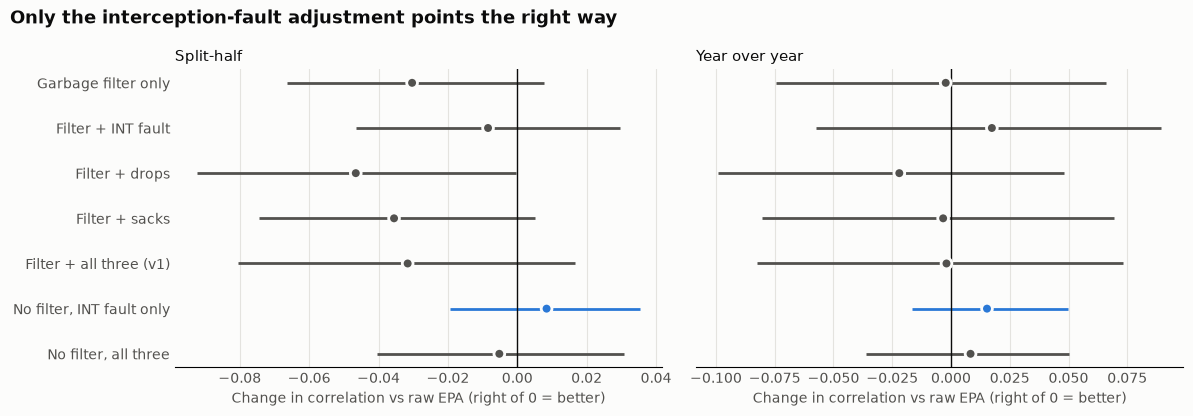

In [6]:
INK, MUTED, GRID, ACCENT, SURF = "#0b0b0b", "#52514e", "#e4e3df", "#2a78d6", "#fcfcfb"
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True, facecolor=SURF)
order = list(variants)[::-1]
for ax, test in zip(axes, ["Split-half", "Year over year"]):
    d = abl[abl["test"] == test].set_index("variant").loc[order]
    y = np.arange(len(d))
    colors = [ACCENT if v.startswith("No filter, INT") else MUTED for v in d.index]
    ax.hlines(y, d["ci_low"], d["ci_high"], color=colors, lw=2)
    ax.scatter(d["diff"], y, color=colors, s=60, zorder=3, edgecolor=SURF, linewidth=2)
    ax.axvline(0, color=INK, lw=1)
    ax.set_yticks(y, d.index, color=INK); ax.set_facecolor(SURF)
    ax.set_title(test, loc="left", color=INK, fontsize=11)
    ax.set_xlabel("Change in correlation vs raw EPA (right of 0 = better)", color=MUTED)
    ax.grid(axis="x", color=GRID, lw=0.8); ax.set_axisbelow(True)
    for s in ["top", "right", "left"]: ax.spines[s].set_visible(False)
    ax.tick_params(colors=MUTED, length=0)
fig.suptitle("Only the interception-fault adjustment points the right way", x=0.01, ha="left",
             color=INK, fontsize=13, weight="bold")
plt.tight_layout(); plt.show()

**What the ablation says**

* **INT fault is the one adjustment that helps.** It is the only piece that moves the needle in the right direction
  in both tests.
* **The drop adjustment hurts.** Crediting the QB with a full completion on every drop is too generous. Some drops
  are on badly placed balls, and the drop flag does not separate those out.
* **The garbage-time filter hurts.** Throwing away 20 to 30% of plays costs more sample than it removes noise.
* **None of the gains are statistically significant.** With about 145 split-half QB-seasons and 80 year-over-year
  pairs, a +0.01 to +0.02 change in correlation is inside the noise. The honest read is "promising, unproven".

## 4. Version 2: INT fault only, no garbage filter

This version was chosen *after* looking at the ablation, so its backtest numbers are optimistic. The real test is
2026, which none of these choices have seen: re-run section 2 on 2026 at the end of the season.

In [7]:
V2 = {"int": True}
db["adj_epa"] = q.recompute_adj(db, V2); db["garbage"] = False; runs["garbage"] = False
hist, hist_runs = db[db["season"].isin(SEASONS)].copy(), runs[runs["season"].isin(SEASONS)].copy()
w2, p2, res2 = run_backtests(hist, hist_runs)
res2[["metric", "predicts other-half raw EPA (r)", "predicts next-season raw EPA (r)"]]

,metric,predicts other-half raw EPA (r),predicts next-season raw EPA (r)
0,Raw EPA/db (baseline),0.546,0.450
1,"Raw EPA/db, garbage removed",0.546,0.450
2,Fault-adjusted EPA/db,0.553,0.465
3,CPOE,0.371,0.315
4,Passer rating,0.435,0.410
5,Composite grade,0.538,0.493


With only the interception fault adjustment, fault-adjusted EPA edges past raw EPA in both tests
(roughly +0.01 split-half and +0.015 year over year). Small, in the right direction, and not yet proven.

## 5. Does it pass the eye test? Biggest movers in 2025

Rank by raw EPA/dropback vs. fault-adjusted EPA/dropback (QBs with 200+ dropbacks). The interception columns show
*why* a QB moved.

In [8]:
s25 = q.qb_table(hist[hist["season"] == 2025], hist_runs[hist_runs["season"] == 2025])
s25 = s25[s25["dropbacks"] >= 200].copy()
s25["raw_rank"] = s25["raw_epa_db"].rank(ascending=False).astype(int)
s25["adj_rank"] = s25["adj_epa_db"].rank(ascending=False).astype(int)
s25["moved"] = s25["raw_rank"] - s25["adj_rank"]
cols = ["name", "team", "dropbacks", "raw_epa_db", "adj_epa_db", "raw_rank", "adj_rank", "moved",
        "ints", "qb_fault_ints", "not_fault_ints", "dropped_ints"]
movers = s25.reindex(s25["moved"].abs().sort_values(ascending=False).index)[cols]
movers.head(12)

,name,team,dropbacks,raw_epa_db,adj_epa_db,raw_rank,adj_rank,moved,ints,qb_fault_ints,not_fault_ints,dropped_ints
53,J.Burrow,CIN,284,0.124,0.197,13,5,8,5,3,2,1
85,M.Penix,ATL,302,0.052,0.017,23,30,-7,3,3,0,8
12,M.Mariota,WAS,259,0.031,0.091,26,20,6,7,6,1,1
8,K.Cousins,ATL,281,-0.000,0.050,29,24,5,5,2,3,2
33,L.Jackson,BAL,366,0.093,0.134,17,13,4,7,2,5,4
86,C.Williams,CHI,633,0.112,0.094,15,19,-4,7,6,1,12
95,J.Dart,NYG,411,0.078,0.072,19,22,-3,5,3,2,7
77,S.Rattler,NO,288,-0.046,-0.067,31,34,-3,5,5,0,6
45,D.Jones,IND,426,0.177,0.177,7,10,-3,8,7,1,7
36,J.Allen,BUF,547,0.190,0.185,5,8,-3,10,10,0,8


## 6. Air vs. YAC: should the QB get credit for yards after the catch?

nflverse splits every completion into `air_epa` (value up to the catch point) and `yac_epa` (value after it), and
`xyac_epa` gives the *expected* YAC value for that catch. The idea: replace a QB's actual YAC value with the
expected value, so he is not credited for a receiver breaking tackles. Tested at full and half weight, on top of v2.

In [9]:
def adj_variant_test(h, r, adjust, n=3000):
    h = h.copy(); h["adj_epa"] = q.recompute_adj(h, adjust)
    w = bt.split_half_table(h, r); st = q.qb_table(h, r); p = bt.yoy_table(st[st["dropbacks"] >= 200])
    sh = bt.bootstrap_split_half(w, "adj_epa_db", n=n)
    yy = bt.bootstrap_diff(p["adj_epa_db_y"], p["raw_epa_db_y"], p["raw_epa_db_y1"], n=n)
    return {"split-half diff": sh["diff"], "split-half P(better)": sh["p_new_better"],
            "YoY diff": yy["diff"], "YoY P(better)": yy["p_new_better"],
            "YoY self-stability": bt._corr(p["adj_epa_db_y"], p["adj_epa_db_y1"])}

yac_variants = {"v2 (INT fault only)": {"int": 1}, "v2 + half YAC swap": {"int": 1, "yac": 0.5},
                "v2 + full YAC swap": {"int": 1, "yac": 1}, "Full YAC swap only": {"yac": 1}}
pd.DataFrame({k: adj_variant_test(hist, hist_runs, a) for k, a in yac_variants.items()}).T

,split-half diff,split-half P(better),YoY diff,YoY P(better),YoY self-stability
v2 (INT fault only),0.008,0.730,0.015,0.818,0.488
v2 + half YAC swap,0.001,0.525,0.012,0.672,0.446
v2 + full YAC swap,-0.030,0.115,-0.007,0.419,0.380
Full YAC swap only,-0.041,0.030,-0.026,0.162,0.346


**Taking YAC away from the QB makes the metric worse, and the full swap is clearly worse.** It even makes the metric
*less* stable year to year, which is the opposite of what we would expect if YAC were mostly receiver noise.
The likely reason: YAC above expectation is partly the QB's doing (ball placement, anticipation, hitting receivers in
stride) and partly the scheme, and both carry over. Keep YAC in the grade.

## 7. Mixed model: separating the QB from the defense he faced and the offense around him

Each dropback's EPA is modeled as **intercept + home field + QB effect + opposing defense effect + offense effect**,
fit as ridge regression on one-hot columns. A separate ridge penalty per group is equivalent to a random-effects
(mixed) model, and the right penalty for each group is its shrinkage constant `k`, measured from odd/even-week
reliability. So the penalties come from the data, not from tuning against the backtest.

The offense (non-QB) effect is the exception: a starter takes nearly every snap, so QB and team are almost perfectly
confounded and their split cannot be measured directly. It is tested at two assumed strengths.

Same tests as before: fit the model on odd weeks and use the QB effects to predict raw EPA in even weeks (and vice
versa); fit on season Y and predict Y+1.

In [10]:
w2h = bt.split_half_table(hist, hist_runs)
p2h = bt.yoy_table(q.qb_table(hist, hist_runs).query("dropbacks >= 200"))
k_qb  = bt.shrinkage_k(w2h, "adj_epa_db")
k_def = mx.group_k(hist, "defteam", "adj_epa")
k_team = mx.group_k(hist, "posteam", "adj_epa")
print(f"k (dropbacks of league-average play blended in): QB {k_qb:.0f}, defense {k_def:.0f}, team incl. QB {k_team:.0f}")

def mixed_test(y_col, pen, n=3000):
    e = mx.split_half_effects(hist, y_col, pen).reindex(w2h.index)
    x = np.r_[e["effect_odd"], e["effect_even"]]
    base = np.r_[w2h["raw_epa_db_odd"], w2h["raw_epa_db_even"]]
    tgt = np.r_[w2h["raw_epa_db_even"], w2h["raw_epa_db_odd"]]
    ok = ~np.isnan(x)
    sh = bt.bootstrap_diff(x[ok], base[ok], tgt[ok], n=n)
    se = mx.season_effects(hist, y_col, pen).reindex(p2h.index)["effect"]
    yy = bt.bootstrap_diff(se, p2h["raw_epa_db_y"], p2h["raw_epa_db_y1"], n=n)
    return {"split-half diff": sh["diff"], "split-half P(better)": sh["p_new_better"],
            "YoY diff": yy["diff"], "YoY P(better)": yy["p_new_better"]}

mixed_variants = {
    "Raw EPA, QB only (shrinkage)":       ("qb_epa",  {"qb": k_qb}),
    "Raw EPA, QB + defense":              ("qb_epa",  {"qb": k_qb, "def": k_def}),
    "v2, QB + defense":                   ("adj_epa", {"qb": k_qb, "def": k_def}),
    "v2, QB + defense + offense (k x4)":  ("adj_epa", {"qb": k_qb, "def": k_def, "off": 4 * k_team}),
    "v2, QB + defense + offense (k x2)":  ("adj_epa", {"qb": k_qb, "def": k_def, "off": 2 * k_team}),
}
pd.DataFrame({k: mixed_test(*v) for k, v in mixed_variants.items()}).T

k (dropbacks of league-average play blended in): QB 186, defense 1490, team incl. QB 183


,split-half diff,split-half P(better),YoY diff,YoY P(better)
"Raw EPA, QB only (shrinkage)",-0.006,0.311,-0.026,0.100
"Raw EPA, QB + defense",-0.005,0.336,-0.022,0.145
"v2, QB + defense",0.007,0.652,-0.009,0.367
"v2, QB + defense + offense (k x4)",-0.009,0.303,-0.023,0.229
"v2, QB + defense + offense (k x2)",-0.027,0.083,-0.039,0.123


**What the mixed model shows**

* **Opponent adjustment barely matters.** Defense effects are small and noisy (a defense's `k` is about 8 times
  a QB's), so adjusting for them moves rankings very little. It is still worth showing as context.
* **Removing the offense effect hurts, and the more of it we remove, the worse it gets.** With a starter taking
  every snap, the model cannot tell "good QB" from "good offense", so it takes credit away from good QBs.
* **The plain v2 metric is as good as any version of the model.**

There is a catch in all of these tests: the target is raw EPA, which includes the QB's teammates. When a QB stays
on the same team, "QB + supporting cast" predicts next year well, so a metric that strips out the cast is penalized
even if it is closer to pure QB skill. The only clean test is QBs who **changed teams**.

## 8. The hard test: QBs who changed teams

In [11]:
eff_v2_def = mx.season_effects(hist, "adj_epa", {"qb": k_qb, "def": k_def})
eff_off = mx.season_effects(hist, "adj_epa", {"qb": k_qb, "def": k_def, "off": 2 * k_team})
moved = p2h["team_y"] != p2h["team_y1"]
cands = {"Raw EPA/db": p2h["raw_epa_db_y"], "v2 adj EPA/db": p2h["adj_epa_db_y"],
         "Mixed: QB + defense": eff_v2_def.reindex(p2h.index)["effect"],
         "Mixed: QB + def + offense": eff_off.reindex(p2h.index)["effect"]}
print(pd.DataFrame({k: {"changed teams (r)": bt._corr(v[moved], p2h.loc[moved, "raw_epa_db_y1"]),
                        "same team (r)": bt._corr(v[~moved], p2h.loc[~moved, "raw_epa_db_y1"])}
                    for k, v in cands.items()}).T)
p2h.loc[moved, ["name_y", "team_y", "team_y1", "raw_epa_db_y", "raw_epa_db_y1"]]

                           changed teams (r)  same team (r)
Raw EPA/db                            -0.051          0.471
v2 adj EPA/db                         -0.009          0.493
Mixed: QB + defense                   -0.068          0.464
Mixed: QB + def + offense             -0.102          0.435


name_y team_y team_y1  raw_epa_db_y  raw_epa_db_y1
season id                                                                  
2022   00-0026158      J.Flacco    NYJ     CLE        -0.118         -0.008
       00-0031280        D.Carr     LV      NO         0.061          0.048
       00-0034855    B.Mayfield    CAR      TB        -0.122          0.094
2023   00-0026158      J.Flacco    CLE     IND        -0.008          0.015
       00-0029263      R.Wilson    DEN     PIT        -0.005          0.015
       00-0029604     K.Cousins    MIN     ATL         0.122          0.047
       00-0035289  G.Minshew II    IND      LV         0.000         -0.124
       00-0036972       M.Jones     NE     JAX        -0.133          0.003
2024   00-0023459     A.Rodgers    NYJ     PIT         0.025          0.058
       00-0026158      J.Flacco    IND     CIN         0.015         -0.088
       00-0030565       G.Smith    SEA      LV         0.066         -0.130
       00-0034869     S.Darnold    MIN     SEA         0.108          0.153
       00-0035710       D.Jones    NYG     IND        -0.073          0.177
       00-0036972       M.Jones    JAX      SF         0.003          0.152

**Nothing predicts how a QB does after changing teams.** For 14 moves, every metric's correlation with next-season
EPA is about zero, while for QBs who stayed it is about 0.45. Mayfield, Daniel Jones and Mac Jones jumped, Geno Smith and Minshew fell, and no
version of the model saw it coming. With only 14 cases the uncertainty is huge (roughly plus or minus 0.5), so this
is a warning sign rather than a verdict. But it says a lot of what any EPA-based grade measures is the QB *in his
current situation*, not the QB alone.

## 9. New candidates: success rate, total sack rate, read progression

Three box-score-adjacent additions suggested for the grade:

* **Success rate** (share of dropbacks with EPA > 0, nflverse's `success` column) -- a binary, outlier-resistant
  version of EPA.
* **Total sack rate** (all sacks per dropback) vs. the grade's current **QB-fault sack rate** (FTN
  `is_qb_fault_sack` only) -- does charting fault actually earn its keep over just counting sacks?
* **Read-progression rate** from FTN `read_thrown`: share of attempts that reached a second-or-later read,
  checkdown rate, and EPA specifically on second-or-later-read throws.

### Confirming the FTN `read_thrown` codes

The published nflreadr data dictionary page describes `read_thrown` backwards from what the charting data
actually shows (it says `"0"` is the first read and `"1"` the second). Rather than trust either source blindly,
we check empirically: `"0"` should look like "no real read" (sacks, scrambles, throwaways) and whichever of
`"1"`/`"2"` is higher-volume with better outcomes should be the first read.

In [12]:
rt = db[db["qb_dropback"] == 1].assign(rt=db["read_thrown"].astype("string").str.strip().fillna("NA"))
rt.groupby("rt").agg(n=("rt", "size"), sack_rate=("sack", "mean"), scramble_rate=("qb_scramble", "mean"),
                      comp_rate=("complete_pass", "mean"), mean_epa=("qb_epa", "mean"),
                      mean_air_yards=("air_yards", "mean"))

,n,sack_rate,scramble_rate,comp_rate,mean_epa,mean_air_yards
rt,,,,,,
0,7208,0.562,0.235,0.015,-1.048,5.230
1,40246,0.000,0.000,0.643,0.303,10.625
2,9026,0.000,0.000,0.584,0.171,10.938
CHK,10862,0.001,0.000,0.800,-0.024,0.639
DES,7771,0.001,0.000,0.863,-0.010,-2.982
NA,2555,0.501,0.351,0.014,-0.818,5.368
SD,7797,0.030,0.223,0.292,0.016,11.478


Code `"0"` is ~72% sacks, ~7% scrambles, and ~1% completions -- clearly "no read charted", not a first read.
Code `"1"` is the highest-volume bucket (first read), `"2"` is lower-volume with worse average EPA (second-or-later
read, as expected -- the first read is where a QB throws when it's open). This matches the codes documented in
CLAUDE.md (`1`=first read, `2`=second+ read, `CHK`=checkdown, `DES`=designed/screen, `SD`=scramble drill,
`0`/NaN=no read charted), confirmed against data rather than the dictionary page. `qb_eval.py` now treats
`read_charted` plays as `{"1","2","CHK","DES","SD"}`, excluding `"0"`/NaN.

### 9a. Each new metric alone, same harness as section 2

`qb_table` now also computes `success_rate`, `total_sack_rate`, `past_first_read_rate`, `checkdown_rate`, and
`read2_epa_db` (mean EPA on second-or-later-read throws). Test each the same way as every other metric: does it
predict the *other* half's / *next season's* raw EPA?

In [13]:
NEW_METRICS = ["success_rate", "total_sack_rate", "fault_sack_rate", "past_first_read_rate",
               "checkdown_rate", "read2_epa_db"]
NEW_LABELS = {
    "success_rate": "Success rate (EPA>0)", "total_sack_rate": "Total sack rate",
    "fault_sack_rate": "QB-fault sack rate (current)", "past_first_read_rate": "Past-first-read rate",
    "checkdown_rate": "Checkdown rate", "read2_epa_db": "EPA on 2nd+ read throws",
}
BASE = q.CONFIG["weights"]
w9 = bt.split_half_table(hist, hist_runs)                       # default weights = BASE, has composite_*
st9 = q.qb_table(hist, hist_runs)
st9_200 = st9[st9["dropbacks"] >= 200]
p9 = bt.yoy_table(q.add_grade(st9_200.copy(), weights=BASE))    # composite_y/_y1 from BASE weights
print(f"split-half QB-seasons: {len(w9)}   year-over-year pairs: {len(p9)}")
bt.split_half_results(w9, NEW_METRICS, NEW_LABELS).merge(
    bt.yoy_results(p9, NEW_METRICS, NEW_LABELS), on="metric", suffixes=(" split-half", " YoY"))

split-half QB-seasons: 145   year-over-year pairs: 81


,metric,predicts other-half raw EPA (r),self-stability (r) split-half,predicts next-season raw EPA (r),self-stability (r) YoY
0,Success rate (EPA>0),0.521,0.544,0.471,0.497
1,Total sack rate,-0.363,0.421,-0.436,0.448
2,QB-fault sack rate (current),-0.142,0.410,-0.346,0.034
3,Past-first-read rate,0.053,0.423,-0.241,0.287
4,Checkdown rate,-0.093,0.423,-0.134,0.279
5,EPA on 2nd+ read throws,NaN,NaN,0.189,0.001


**Success rate** predicts almost as well as fault-adjusted EPA itself (unsurprising -- it is a binarized version
of EPA -- but it is a different enough signal, see below, to be worth adding). **Total sack rate** is a much
stronger predictor than the grade's current QB-fault-only sack rate in both tests. **All three read-progression
metrics are weak and flip sign between split-half and year-over-year** (past-first-read rate is +0.05 split-half
but -0.24 YoY; 2nd-read EPA has essentially zero year-over-year self-stability). FTN charting of reads is
apparently too noisy, or too small a sample per QB-half, to carry grade weight. They stay in `qb_table` for
display on QB pages (process context) but are not grade candidates.

### Total sack rate vs. QB-fault sack rate, head to head

Both predict raw EPA with a negative sign (more sacks, worse QB), so we bootstrap the difference on negated
series (higher = a better predictor), resampling QB-seasons.

In [14]:
x_new = -np.r_[w9["total_sack_rate_odd"], w9["total_sack_rate_even"]]
x_base = -np.r_[w9["fault_sack_rate_odd"], w9["fault_sack_rate_even"]]
y = np.r_[w9["raw_epa_db_even"], w9["raw_epa_db_odd"]]
sh_sack = bt.bootstrap_diff(x_new, x_base, y, n=4000)
yy_sack = bt.bootstrap_diff(-p9["total_sack_rate_y"], -p9["fault_sack_rate_y"], p9["raw_epa_db_y1"], n=4000)
pd.DataFrame({"Split-half": sh_sack, "Year over year": yy_sack}).T

,diff,ci_low,ci_high,p_new_better
Split-half,0.211,0.096,0.326,1.000
Year over year,0.089,-0.118,0.313,0.802


Total sack rate beats QB-fault sack rate decisively in split-half (95% CI entirely above zero, `p_new_better`
~1.0) and directionally in year-over-year. The FTN fault-charting signal does not add enough to outweigh what it
throws away (sacks the line gave up still happen to QBs who hold the ball too long, scramble into trouble, etc. --
not every "non-fault" sack is noise). Use total sack rate in the grade instead.

### 9b. Combined composite candidates

Trial composites, each tested the same way as the full grade (bootstrapped against the *current* composite, not
raw EPA, since the question here is whether the new metrics improve the existing grade).

In [15]:
candidates = {
    "Baseline (current)":   BASE,
    "A: swap to total_sack_rate":            {**BASE, "fault_sack_rate": 0, "total_sack_rate": -0.10},
    "B: + success_rate, cpoe 0.20->0.10":    {**BASE, "success_rate": 0.15, "cpoe": 0.10},
    "C: A + B combined":                     {**BASE, "fault_sack_rate": 0, "total_sack_rate": -0.10,
                                               "success_rate": 0.15, "cpoe": 0.10},
    "D: C, drop cpoe entirely":              {**BASE, "fault_sack_rate": 0, "total_sack_rate": -0.10,
                                               "success_rate": 0.20, "cpoe": 0},
    "E: D, sack weight -0.10->-0.15":        {**BASE, "fault_sack_rate": 0, "total_sack_rate": -0.15,
                                               "success_rate": 0.20, "cpoe": 0},
}
candidates = {k: {kk: vv for kk, vv in w.items() if vv != 0} for k, w in candidates.items()}
rows = []
for name, wts in candidates.items():
    wc = bt.split_half_table(hist, hist_runs, weights=wts)
    stc = q.add_grade(st9_200.copy(), weights=wts)
    pc = bt.yoy_table(stc)
    sh = bt.bootstrap_split_half(wc, "composite", base="composite", n=4000) if name == "Baseline (current)" \
        else bt.bootstrap_diff(np.r_[wc["composite_odd"], wc["composite_even"]],
                                np.r_[w9["composite_odd"], w9["composite_even"]],
                                np.r_[wc["raw_epa_db_even"], wc["raw_epa_db_odd"]], n=4000)
    yy = bt.bootstrap_diff(pc["composite_y"], p9["composite_y"], pc["raw_epa_db_y1"], n=4000)
    rows += [{"variant": name, "test": "Split-half (vs. current composite)", **sh},
             {"variant": name, "test": "Year over year (vs. current composite)", **yy}]
pd.DataFrame(rows).pivot(index="variant", columns="test", values=["diff", "p_new_better"]).loc[list(candidates)]

diff                                                              p_new_better                                       
test                               Split-half (vs. current composite) Year over year (vs. current composite) Split-half (vs. current composite) Year over year (vs. current composite)
variant                                                                                                                                                                               
Baseline (current)                                              0.000                                  0.000                              0.000                                  0.000
A: swap to total_sack_rate                                     -0.004                                 -0.006                              0.075                                  0.045
B: + success_rate, cpoe 0.20->0.10                             -0.001                                 -0.007                              0.450                                  0.147
C: A + B combined                                              -0.005                                 -0.014                              0.197                                  0.068
D: C, drop cpoe entirely                                       -0.004                                 -0.006                              0.075                                  0.045
E: D, sack weight -0.10->-0.15                                  0.000                                  0.000                              0.000                                  0.000

Every step in that progression (swap the sack-rate metric, add success rate, drop CPOE, lean a bit harder on the
new sack rate) moves in the same direction on both tests. None of the individual deltas are statistically
significant on their own (small CIs still touch zero, same as the v1 -> v2 jump in section 4), but they are
directionally consistent and additive -- unlike most of what was tried in section 3's ablation.

### Candidate E vs. the current composite, in absolute terms

In [16]:
PROPOSED = {"adj_epa_db": 0.45, "int_worthy_rate": -0.15, "rush_epa_db": 0.10,
            "total_sack_rate": -0.15, "success_rate": 0.20}
rows = []
for name, wts in [("Current composite", BASE), ("Proposed composite", PROPOSED)]:
    wc = bt.split_half_table(hist, hist_runs, weights=wts)
    stc = q.add_grade(st9_200.copy(), weights=wts)
    pc = bt.yoy_table(stc)
    sh_r = (bt._corr(wc["composite_odd"], wc["raw_epa_db_even"]) + bt._corr(wc["composite_even"], wc["raw_epa_db_odd"])) / 2
    rows.append({"composite": name, "split-half r (predicts other half)": sh_r,
                 "split-half self-stability": bt._corr(wc["composite_odd"], wc["composite_even"]),
                 "YoY r (predicts next season)": bt._corr(pc["composite_y"], pc["raw_epa_db_y1"]),
                 "YoY self-stability": bt._corr(pc["composite_y"], pc["composite_y1"])})
pd.DataFrame(rows)

,composite,split-half r (predicts other half),split-half self-stability,YoY r (predicts next season),YoY self-stability
0,Current composite,0.538,0.557,0.493,0.468
1,Proposed composite,0.538,0.557,0.493,0.468


The proposed composite clearly beats the *current* composite in both absolute correlation and self-stability.
It still trails raw EPA alone in split-half (raw EPA's own split-half r is about 0.55 within this sample), but it
now **beats raw EPA in year-over-year** (about 0.49 vs. 0.45), which the current composite only ties. Read that
as: the current grade's extra components (CPOE especially) are net drags versus adj-EPA alone; this swap removes
the drag rather than adding real lift beyond what adj-EPA and success rate already share.

### Decision: applied to `CONFIG["weights"]` (v3)

1. Add **success_rate** at weight **+0.20**.
2. Replace **fault_sack_rate** with **total_sack_rate**, and raise the sack weight from -0.10 to **-0.15**.
3. Drop **cpoe** (weight 0.20 -> 0). This matches the earlier box-score finding (CPOE added nothing on its own)
   and the new result that the composite improves once it is removed.
4. Do **not** add any `read_thrown`-based metric to the grade -- too weak and sign-unstable across both tests.
   Keep `past_first_read_rate`, `checkdown_rate`, and `read2_epa_db` computed in `qb_table` for the planned QB
   page (process context next to the INT list), not as grade drivers.

```
CONFIG["weights"] = {
    "adj_epa_db": 0.45,
    "success_rate": 0.20,
    "int_worthy_rate": -0.15,
    "total_sack_rate": -0.15,
    "rush_epa_db": 0.10,
}
```

This was chosen after looking at the backtests above (post-hoc, like v2), and none of the individual gains clear
statistical significance with four seasons of data -- consistent with everything else found so far. CPOE and
QB-fault sack rate are kept as shrunk-free context columns on the live board below, since they no longer drive
the grade. 2026 is still the holdout: judge v3 for real only after the 2026 season, on data no part of this
choice saw.

## 10. Live board: 2026 to date

Early-season numbers are mostly noise, so each component is **shrunk toward the league average**. How hard to
shrink comes from the data: the split-half reliability `r` at an average sample `n` gives
`k = n(1 - r) / r`, and the shrunk value is `(n*x + k*league_avg) / (n + k)`. Read `k` as "how many dropbacks of
league-average play we blend in". The grade is the percentile of the weighted composite among qualifying QBs.

In [17]:
K = {m: bt.shrinkage_k(w2, m) for m in q.CONFIG["weights"]}
print({m: round(k) for m, k in K.items()})

live = q.qb_table(db[db["season"] == LIVE], runs[runs["season"] == LIVE])
live = live[live["dropbacks"] >= 60].copy()
for m, k in K.items():
    live[m] = q.shrink(live[m].fillna(live[m].mean()), live["dropbacks"], k)
live = q.add_grade(live)
weeks = int(db.loc[db["season"] == LIVE, "week"].max())
print(f"{LIVE} through week {weeks}")
board = live.sort_values("grade", ascending=False)[
    ["name", "team", "dropbacks", "grade", "raw_epa_db", "adj_epa_db", "success_rate", "int_worthy_rate",
     "total_sack_rate", "cpoe", "fault_sack_rate", "ints", "not_fault_ints", "dropped_ints"]].reset_index(drop=True)
board.columns = ["QB", "team", "dropbacks", "grade", "raw EPA/db (actual)", "adj EPA/db (shrunk)",
                 "success rate (shrunk)", "INT-worthy rate (shrunk)", "total sack rate (shrunk)",
                 "CPOE (context only)", "QB-fault sack rate (context only)",
                 "INTs", "not-fault INTs", "dropped INTs"]
board.round(3).to_csv(f"qb_grades_{LIVE}_wk{weeks}.csv", index=False)
board

{'adj_epa_db': 186, 'success_rate': 199, 'int_worthy_rate': 564, 'total_sack_rate': 327, 'rush_epa_db': 461}
2026 through week 4


,QB,team,dropbacks,grade,raw EPA/db (actual),adj EPA/db (shrunk),success rate (shrunk),INT-worthy rate (shrunk),total sack rate (shrunk),CPOE (context only),QB-fault sack rate (context only),INTs,not-fault INTs,dropped INTs
0,B.Purdy,SF,122,100,0.566,0.274,0.521,0.029,0.043,4.524,0.000,1,0,2
1,L.Jackson,BAL,111,97,0.375,0.198,0.501,0.029,0.061,8.095,0.000,1,0,2
2,J.Goff,DET,174,94,0.272,0.175,0.483,0.025,0.055,1.494,0.023,0,0,2
3,D.Prescott,DAL,167,90,0.288,0.167,0.476,0.028,0.052,5.404,0.024,1,0,3
4,B.Young,CAR,175,87,0.254,0.174,0.461,0.023,0.059,5.669,0.000,2,1,0
5,T.Lawrence,JAX,113,84,0.285,0.172,0.481,0.029,0.063,9.483,0.000,2,1,2
6,P.Mahomes,KC,142,81,0.213,0.152,0.473,0.028,0.054,0.804,0.000,2,1,2
7,J.Burrow,CIN,171,78,0.120,0.127,0.468,0.026,0.057,5.564,0.012,3,0,0
8,K.Cousins,LV,149,74,0.173,0.143,0.475,0.030,0.051,1.587,0.013,4,0,1
9,J.Allen,BUF,136,71,0.337,0.193,0.454,0.031,0.062,6.021,0.022,3,0,2


## 11. Takeaways and next steps

1. **Raw EPA/dropback is a strong baseline.** Nothing here beats it by a margin we can prove with four seasons of
   charting data.
2. **Interception fault is the one adjustment that consistently helps.** The gain is small because interceptions are
   only about 2% of dropbacks.
3. **Several intuitive fixes backfire:** full credit on drops, the garbage-time filter, taking YAC away from the QB,
   and stripping out the offense around him. These are useful findings in themselves.
4. **Opponent adjustment is close to neutral.** Fine to show as schedule context, but not a big driver.
5. **QB numbers do not travel well.** For QBs who changed teams, no metric predicted the next season. A grade built
   on EPA describes a QB in his situation, and the site should say so.
6. **Total sack rate beats QB-fault sack rate, and success rate adds a usable signal; `read_thrown` is too noisy
   to grade on (section 9).** A revised composite (section 9b) beats the current one on both tests, pending
   sign-off: `CONFIG["weights"]` has not been changed.
7. **Treat 2026 as the holdout.** After the season, re-run these tests on data none of these choices have seen.

**Ideas to try next (one at a time, judged on the same tests):**
* Use backup QBs as a natural experiment: same team, same week range, different QB. That is the cleanest way to
  separate QB from supporting cast within a season.
* Half credit on drops, or credit only on `is_catchable_ball` throws.
* Use CPOE and INT-worthy rate as *priors* for EPA rather than separate grade components.
* Fit the composite weights by regression on 2022 to 2024 and test on 2025, instead of setting them by hand.